In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv("csv/Mfg_Sales.csv")
print(df.head())

        AcYr   MMYYYY  Zone BranchName  MKTType                    BrandName  \
0  2020-2021  2020-04  EAST    CUTTACK  PILLAR             CARACSOL EYE DROP   
1  2020-2021  2020-04  EAST    CUTTACK  PILLAR     ENTEROMYCETIN CAPLETS-500   
2  2020-2021  2020-04  EAST    CUTTACK  PILLAR        ENTEROMYCETIN CAPS-250   
3  2020-2021  2020-04  EAST    CUTTACK  PILLAR   Enteromycetin OTIC SOLUTION   
4  2020-2021  2020-04  EAST    CUTTACK  PILLAR      ENTEROMYCETIN SUSPENSION   

   SalesQty   SalesAmt  CNQty    CNAmt  ActQty     ActAmt  Unnamed: 12  \
0     725.0   16776.50    1.0    21.21     724   16755.29          NaN   
1    4575.0  201426.25   50.0  2250.00    4525  199176.25          NaN   
2     187.0    7190.15   45.0  1735.65     142    5454.50          NaN   
3    2900.0   55941.00    NaN      NaN    2900   55941.00          NaN   
4    1260.0   61072.20    NaN      NaN    1260   61072.20          NaN   

  Unnamed: 13  
0         NaN  
1         NaN  
2           `  
3         

In [3]:
df.isna().sum().sort_values(ascending=False)

Unnamed: 12    54321
Unnamed: 13    54320
CNQty          15477
CNAmt          14942
SalesAmt        4511
SalesQty        4511
MKTType          126
BrandName        107
Zone              12
AcYr               0
BranchName         0
MMYYYY             0
ActAmt             0
ActQty             0
dtype: int64

In [4]:
# Find missing values in the current all_data
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]

print("Features with missing values:")
print(missing_data)

Features with missing values:
Unnamed: 12    54321
Unnamed: 13    54320
CNQty          15477
CNAmt          14942
SalesAmt        4511
SalesQty        4511
MKTType          126
BrandName        107
Zone              12
dtype: int64


In [5]:
df.isna().sum().sort_values(ascending=False)

Unnamed: 12    54321
Unnamed: 13    54320
CNQty          15477
CNAmt          14942
SalesAmt        4511
SalesQty        4511
MKTType          126
BrandName        107
Zone              12
AcYr               0
BranchName         0
MMYYYY             0
ActAmt             0
ActQty             0
dtype: int64

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54321 entries, 0 to 54320
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AcYr         54321 non-null  object 
 1   MMYYYY       54321 non-null  object 
 2   Zone         54309 non-null  object 
 3   BranchName   54321 non-null  object 
 4   MKTType      54195 non-null  object 
 5   BrandName    54214 non-null  object 
 6   SalesQty     49810 non-null  float64
 7   SalesAmt     49810 non-null  float64
 8   CNQty        38844 non-null  float64
 9   CNAmt        39379 non-null  float64
 10  ActQty       54321 non-null  int64  
 11  ActAmt       54321 non-null  float64
 12  Unnamed: 12  0 non-null      float64
 13  Unnamed: 13  1 non-null      object 
dtypes: float64(6), int64(1), object(7)
memory usage: 5.8+ MB
None


In [7]:
# Impute numerical features with 0
numerical_cols_to_impute_zero = df.select_dtypes(include=['float64', 'object']).columns.tolist()
for col in numerical_cols_to_impute_zero:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')
        elif df[col].dtype == 'float64':
            df[col]= df[col].fillna(df[col].median())

C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [8]:
print(df.isna().any())

AcYr           False
MMYYYY         False
Zone           False
BranchName     False
MKTType        False
BrandName      False
SalesQty       False
SalesAmt       False
CNQty          False
CNAmt          False
ActQty         False
ActAmt         False
Unnamed: 12     True
Unnamed: 13    False
dtype: bool


In [9]:
df.dropna(axis=1, how = 'all', inplace=True)

In [10]:
df.head()

,AcYr,MMYYYY,Zone,BranchName,MKTType,BrandName,SalesQty,SalesAmt,CNQty,CNAmt,ActQty,ActAmt,Unnamed: 13
0,2020-2021,2020-04,EAST,CUTTACK,PILLAR,CARACSOL EYE DROP,725.0,16776.50,1.0,21.21,724,16755.29,Unknown
1,2020-2021,2020-04,EAST,CUTTACK,PILLAR,ENTEROMYCETIN CAPLETS-500,4575.0,201426.25,50.0,2250.00,4525,199176.25,Unknown
2,2020-2021,2020-04,EAST,CUTTACK,PILLAR,ENTEROMYCETIN CAPS-250,187.0,7190.15,45.0,1735.65,142,5454.50,`
3,2020-2021,2020-04,EAST,CUTTACK,PILLAR,Enteromycetin OTIC SOLUTION,2900.0,55941.00,20.0,831.60,2900,55941.00,Unknown
4,2020-2021,2020-04,EAST,CUTTACK,PILLAR,ENTEROMYCETIN SUSPENSION,1260.0,61072.20,20.0,831.60,1260,61072.20,Unknown


In [11]:
# Drop Unnamed columns
df = df.drop(columns=['Unnamed: 12', 'Unnamed: 13'], errors='ignore')
print(df.columns)  # Verify columns were dropped

Index(['AcYr', 'MMYYYY', 'Zone', 'BranchName', 'MKTType', 'BrandName',
       'SalesQty', 'SalesAmt', 'CNQty', 'CNAmt', 'ActQty', 'ActAmt'],
      dtype='object')


### Step 3: Deep Dive EDA on the Target Variable (`SalePrice`)
The most important variable in our dataset is the one we want to predict. Understanding its characteristics is the first and most critical step in any regression problem.

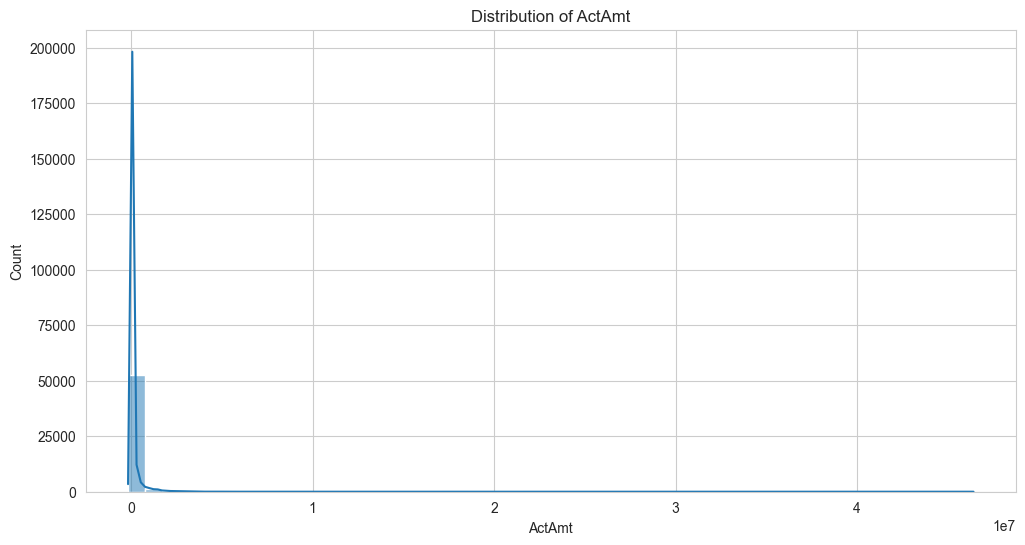

Skewness of ActAmt: 32.68700943564612


In [12]:
plt.figure(figsize=(12,6))
sns.histplot(df['ActAmt'],kde=True,bins=50)
plt.title('Distribution of ActAmt')
plt.xlabel('ActAmt')
plt.show()
print(f"Skewness of ActAmt: {df['ActAmt'].skew()}")

#### **Theoretical Concept: Skewness and Log Transformation**
The distribution of `SalePrice` is **positively skewed** (or right-skewed). This means there's a long tail of very expensive houses, which can negatively impact the performance of some models, especially linear models like Linear Regression. These models often assume that the variables (and especially the residuals of the model) are normally distributed.

To fix this, we can apply a **log transformation** (`np.log1p`, which is `log(1+x)` to handle potential zero values). This transformation compresses the range of large values, making the distribution more symmetrical and closer to a normal distribution.

C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


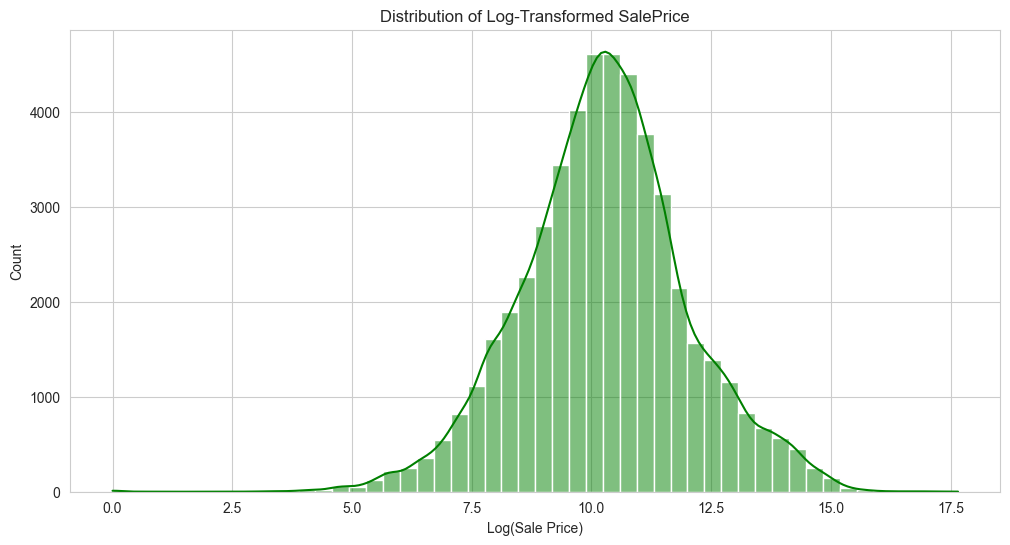

Skewness of Log-Transformed SalePrice: -0.06021116349452412


In [13]:
df['ActAmt'] = np.log1p(df['ActAmt'])

plt.figure(figsize=(12, 6))
sns.histplot(df['ActAmt'], kde=True, bins=50, color='green')
plt.title('Distribution of Log-Transformed SalePrice')
plt.xlabel('Log(Sale Price)')
plt.show()

print(f"Skewness of Log-Transformed SalePrice: {df['ActAmt'].skew()}")

### Step 4: EDA on Feature Variables

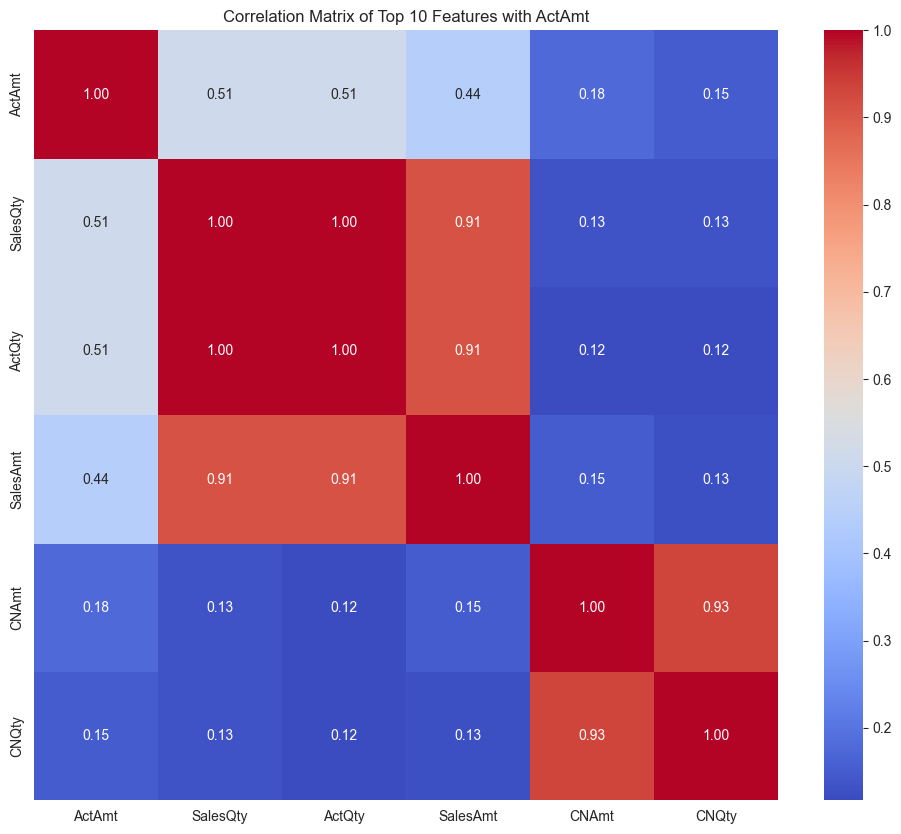

In [14]:
# Find the top 10 features most correlated with SalePrice
corrmat = df.corr(numeric_only=True)
top_corr_features = corrmat.nlargest(10, 'ActAmt')['ActAmt'].index
top_corr_matrix = df[top_corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Top 10 Features with ActAmt')
plt.show()